<a href="https://colab.research.google.com/github/rishidharan-04/detection_phishing_urls/blob/main/Phishing_URLs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **LOADING AND CHECKING THE DATASET**

In [ ]:
import pandas as pd

# Define the file path
file_path = "/content/Training.parquet"


# Load the dataset
df = pd.read_parquet(file_path)

# Display the first few rows
print("Dataset Preview:")
print(df.head())

# Display basic information about the dataset
print("\nDataset Info:")
print(df.info())

# Check for missing values
print("\nMissing Values in Each Column:")
print(df.isnull().sum())

# Summary statistics
print("\nSummary Statistics:")
print(df.describe())


Dataset Preview:
                                                 url  length_url  \
0  https://www.todayshomeowner.com/how-to-make-ho...          82   
1  http://thapthan.ac.th/information/confirmation...          93   
2  http://app.dialoginsight.com/T/OFC4/L2S/3888/B...         121   
3                           https://www.bedslide.com          24   
4  https://tabs.ultimate-guitar.com/s/sex_pistols...          73   

   length_hostname  ip  nb_dots  nb_hyphens  nb_at  nb_qm  nb_and  nb_or  ...  \
0               23   0        2           7      0      0       0      0  ...   
1               14   1        2           0      0      0       0      0  ...   
2               21   1        3           0      0      0       0      0  ...   
3               16   0        2           0      0      0       0      0  ...   
4               24   0        3           1      0      0       0      0  ...   

   domain_in_title  domain_with_copyright  whois_registered_domain  \
0                

# **VISUALIZATION AND FEATURE EXPLORATION**

<ipython-input-4-f069755a52be>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="status", data=df, palette="coolwarm")


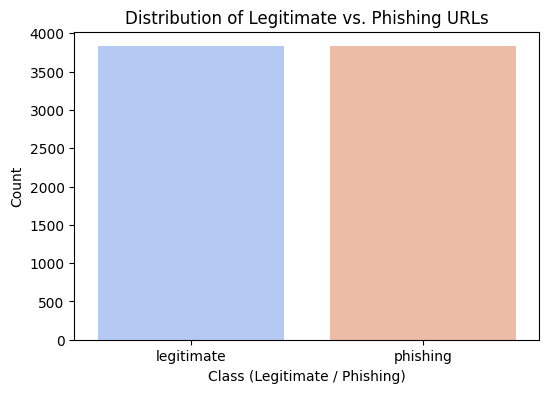

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
sns.countplot(x="status", data=df, palette="coolwarm")
plt.title("Distribution of Legitimate vs. Phishing URLs")
plt.xlabel("Class (Legitimate / Phishing)")
plt.ylabel("Count")
plt.show()


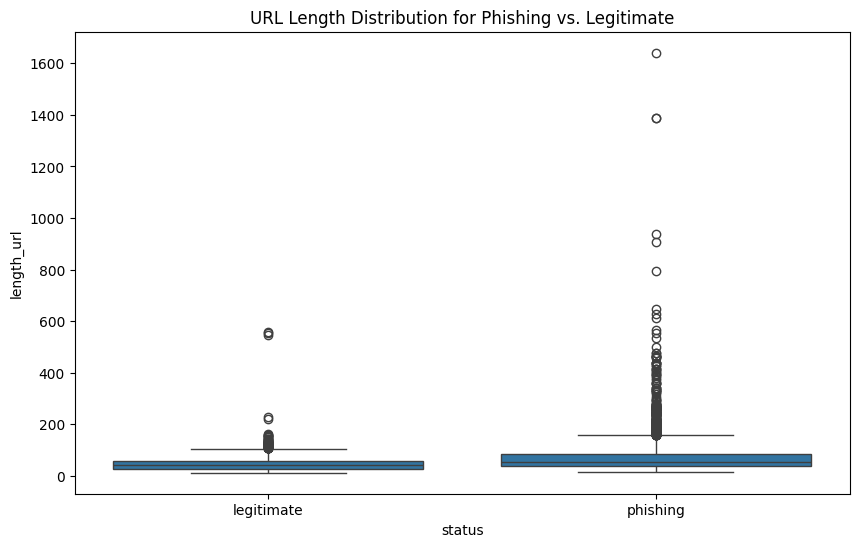

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x="status", y="length_url", data=df)
plt.title("URL Length Distribution for Phishing vs. Legitimate")
plt.show()


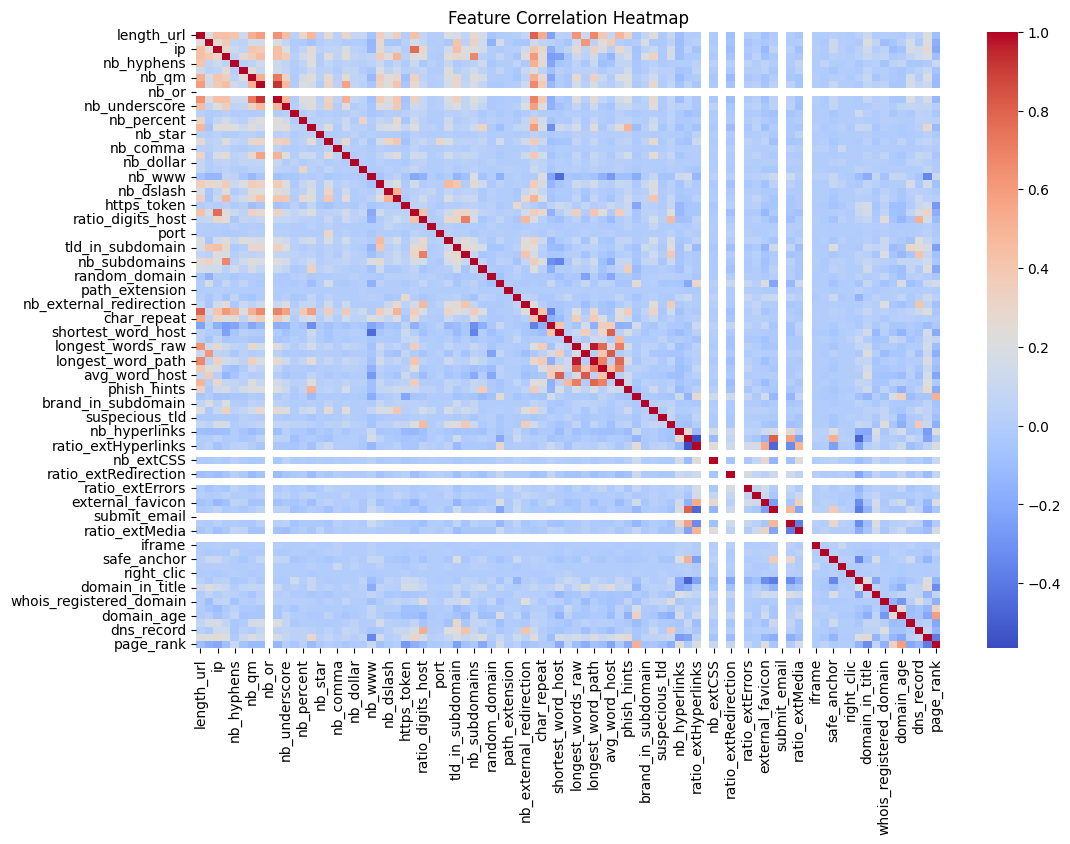

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numeric columns (exclude 'url' and 'status')
numeric_df = df.select_dtypes(include=[np.number])

# Plot the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), cmap="coolwarm", annot=False)
plt.title("Feature Correlation Heatmap")
plt.show()


In [ ]:
# Convert 'status' to numerical (0 = legitimate, 1 = phishing)
df["status"] = df["status"].map({"legitimate": 0, "phishing": 1})

# Drop non-numeric columns (like 'url')
df_numeric = df.select_dtypes(include=['number'])

# Compute correlation with target variable
correlation_with_target = df_numeric.corr()["status"].abs().sort_values(ascending=False)

# Display the top 15 most correlated features
print(correlation_with_target.head(15))


status                 1.000000
google_index           0.734620
page_rank              0.503594
nb_www                 0.440457
ratio_digits_url       0.354270
nb_hyperlinks          0.342196
domain_in_title        0.335234
phish_hints            0.331244
domain_age             0.323937
ip                     0.311288
nb_qm                  0.295776
ratio_intHyperlinks    0.256211
nb_slash               0.244986
length_hostname        0.242069
length_url             0.235846
Name: status, dtype: float64


In [ ]:
# Reload dataset (if needed)
file_path = "/content/Training.parquet"
df = pd.read_parquet(file_path)

# Convert 'status' to numerical again
df["status"] = df["status"].map({"legitimate": 0, "phishing": 1})

# Check if the mapping worked
print(df["status"].unique())  # Should show [0, 1]




[0 1]


In [ ]:
# Ensure only numeric columns are used
df_numeric = df.select_dtypes(include=['number'])

# Compute correlation with target variable
correlation_with_target = df_numeric.corr()["status"].abs().sort_values(ascending=False)

# Display the top 15 most correlated features
print(correlation_with_target.head(15))


status                 1.000000
google_index           0.734620
page_rank              0.503594
nb_www                 0.440457
ratio_digits_url       0.354270
nb_hyperlinks          0.342196
domain_in_title        0.335234
phish_hints            0.331244
domain_age             0.323937
ip                     0.311288
nb_qm                  0.295776
ratio_intHyperlinks    0.256211
nb_slash               0.244986
length_hostname        0.242069
length_url             0.235846
Name: status, dtype: float64


In [ ]:
selected_features = [
    "google_index", "page_rank", "nb_www", "ratio_digits_url",
    "nb_hyperlinks", "domain_in_title", "phish_hints", "domain_age",
    "ip", "ratio_intHyperlinks", "nb_slash", "length_hostname", "length_url"
]

# Create a new DataFrame with selected features
df_selected = df[selected_features + ["status"]]  # Keep 'status' as target


# **TRAINING THE MODEL**

In [ ]:
from sklearn.model_selection import train_test_split

# Ensure the dataset is loaded correctly
if 'df_selected' not in locals():
    print("Dataset is not loaded! Make sure `df_selected` is properly created.")

# Separate features and target
X = df_selected.drop(columns=["status"])  # Features
y = df_selected["status"]  # Target

# Correctly split dataset (without parentheses!)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Print shapes to confirm correct assignment
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_train sample:\n{X_train.head()}")
print(f"y_train sample:\n{y_train.head()}")



X_train shape: (6126, 13)
y_train shape: (6126,)
X_train sample:
      google_index  page_rank  nb_www  ratio_digits_url  nb_hyperlinks  \
6676             1          4       1          0.023256             49   
136              1          0       0          0.000000              6   
1317             1          1       0          0.019231              0   
4577             0          7       0          0.079208             48   
465              1          0       0          0.178571              0   

      domain_in_title  phish_hints  domain_age  ip  ratio_intHyperlinks  \
6676                1            0        8246   0             0.979592   
136                 1            0        1182   0             0.000000   
1317                1            0        2397   0             0.000000   
4577                0            0        9744   0             0.437500   
465                 1            0         529   0             0.000000   

      nb_slash  length_hostname  length

In [ ]:
from sklearn.model_selection import train_test_split

# Ensure dataset is loaded
if 'df_selected' not in locals():
    print("⚠️ Dataset is not loaded! Make sure `df_selected` is properly created.")

# Separate features and target
X = df_selected.drop(columns=["status"])  # Features
y = df_selected["status"]  # Target

# **Check if X or y is empty**
if X.empty or y.empty:
    print("⚠️ Error: X or y is empty! Ensure the dataset is properly prepared.")
else:
    # Split dataset into training (80%) and testing (20%)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    # **Check Shapes**
    print(f"✅ Training set: X_train {X_train.shape}, y_train {y_train.shape}")
    print(f"✅ Testing set: X_test {X_test.shape}, y_test {y_test.shape}")

✅ Training set: X_train (6126, 13), y_train (6126,)
✅ Testing set: X_test (1532, 13), y_test (1532,)


In [ ]:
from sklearn.model_selection import train_test_split

# Ensure dataset is loaded
if 'df_selected' not in locals():
    print("⚠️ Dataset is not loaded! Make sure `df_selected` is properly created.")

# Separate features and target
X = df_selected.drop(columns=["status"])  # Features
y = df_selected["status"]  # Target

# **Check if X or y is empty**
if X.empty or y.empty:
    print("⚠️ Error: X or y is empty! Ensure the dataset is properly prepared.")
else:
    # Split dataset into training (80%) and testing (20%)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    # **Check Shapes**
    print(f"✅ Training set: X_train {X_train.shape}, y_train {y_train.shape}")
    print(f"✅ Testing set: X_test {X_test.shape}, y_test {y_test.shape}")

✅ Training set: X_train (6126, 13), y_train (6126,)
✅ Testing set: X_test (1532, 13), y_test (1532,)


In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

# Initialize the model
gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)

# Train the model
gb_model.fit(X_train, y_train)

print("✅ Model training complete!")


✅ Model training complete!


In [ ]:
import joblib

# Save the trained model
joblib.dump(gb_model, "phishing_model.pkl")
print("✅ Model saved as phishing_model.pkl")


✅ Model saved as phishing_model.pkl


Model Accuracy: 0.9484

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.95      0.95       766
           1       0.95      0.95      0.95       766

    accuracy                           0.95      1532
   macro avg       0.95      0.95      0.95      1532
weighted avg       0.95      0.95      0.95      1532



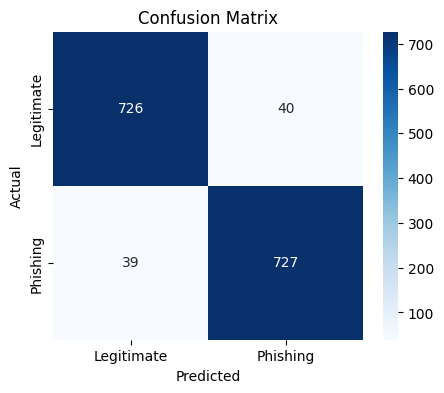

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Predictions on test data
y_pred = gb_model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues", xticklabels=["Legitimate", "Phishing"], yticklabels=["Legitimate", "Phishing"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


# **MAIN PROGRAM**

Telegram Bot - Phisherman Bot - 7760255161:AAFI2Wliq2HMJd5FqtIfMiTA26RqLP1rrPc

In [ ]:
!pip install python-telegram-bot --upgrade


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 673.5/673.5 kB 7.5 MB/s eta 0:00:00


In [ ]:
import joblib
import re
import pandas as pd
import numpy as np
from urllib.parse import urlparse
from telegram import Update
from telegram.ext import Application, CommandHandler, MessageHandler, filters, CallbackContext

# Load the trained model
model = joblib.load("phishing_model.pkl")

import numpy as np
import pandas as pd
from urllib.parse import urlparse
import re

def extract_features(url):
    parsed_url = urlparse(url)
    features = {
        "google_index": 1,  # Placeholder (should be replaced with actual data)
        "page_rank": 3,  # Placeholder (should be replaced with actual data)
        "nb_www": 1 if "www" in parsed_url.netloc else 0,
        "ratio_digits_url": sum(c.isdigit() for c in url) / max(len(url), 1),
        "nb_hyperlinks": url.count("http"),
        "domain_in_title": 1 if "title" in url else 0,
        "phish_hints": 1 if re.search(r"(login|secure|bank|update|verify|account|webscr)", url, re.IGNORECASE) else 0,
        "domain_age": 3650,  # Placeholder (should be replaced with actual WHOIS API data)
        "ip": 1 if re.match(r"^\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}$", parsed_url.netloc) else 0,
        "ratio_intHyperlinks": url.count("http") / max(url.count("/") + 1, 1),
        "nb_slash": url.count("/"),
        "length_hostname": len(parsed_url.hostname) if parsed_url.hostname else 0,
        "length_url": len(url),
    }

    # Ensure feature order matches training data
    feature_order = [
        "google_index", "page_rank", "nb_www", "ratio_digits_url", "nb_hyperlinks",
        "domain_in_title", "phish_hints", "domain_age", "ip", "ratio_intHyperlinks",
        "nb_slash", "length_hostname", "length_url"
    ]

    # Convert to DataFrame in the correct order
    feature_df = pd.DataFrame([[features[col] for col in feature_order]], columns=feature_order)

    # **Fix: Fill any NaN values with 0**
    feature_df = feature_df.fillna(0)

    return feature_df

# Define function to handle URL messages
async def check_url(update: Update, context: CallbackContext):
    url = update.message.text.strip()

    # Auto-correct missing "http://"
    if not url.startswith(("http://", "https://")):
        url = "https://" + url

    # Extract features
    feature_df = extract_features(url)

    # Predict probability instead of class
    prediction_prob = model.predict_proba(feature_df)[0][1]  # Probability of phishing

    # Set a threshold (adjust if needed)
    threshold = 0.80  # Only warn if probability > 80%

    if prediction_prob > threshold:
        message = (
            f"🚨 **Phishing Alert!** 🚨\n\n"
            f"🔗 **URL:** `{url}`\n"
            f"⚠️ This website has an **{prediction_prob:.2%}** chance of being **phishing**.\n\n"
            f"🛑 **Avoid entering sensitive information!**\n"
            f"✅ Always verify the site before proceeding."
        )
    else:
        safe_confidence = (1 - prediction_prob) * 100
        message = (
            f"✅ **Safe URL Detected** 🛡️\n\n"
            f"🔗 **URL:** `{url}`\n"
            f"🔍 This website seems **safe** with a **{safe_confidence:.2f}% confidence**.\n\n"
            f"👍 You can proceed, but always stay alert!"
        )

    await update.message.reply_text(message, parse_mode="Markdown")

# Start the bot
async def main():
    TOKEN = "7760255161:AAE-uF0WBPN1-RxVrSywUPG7L9Y8AMYV3ZQ"

    app = Application.builder().token(TOKEN).build()

    # Add command and message handlers
    app.add_handler(MessageHandler(filters.TEXT & ~filters.COMMAND, check_url))

    # Start the bot
    print("✅ Bot is running...")
    await app.run_polling()

import nest_asyncio
import asyncio

nest_asyncio.apply()  # Allow nested event loops

if __name__ == "__main__":
    loop = asyncio.get_event_loop()
    loop.run_until_complete(main())  # Start the bot


✅ Bot is running...


ERROR:telegram.ext.Application:No error handlers are registered, logging exception.
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/httpx/_transports/default.py", line 101, in map_httpcore_exceptions
    yield
  File "/usr/local/lib/python3.11/dist-packages/httpx/_transports/default.py", line 394, in handle_async_request
    resp = await self._pool.handle_async_request(req)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/httpcore/_async/connection_pool.py", line 256, in handle_async_request
    raise exc from None
  File "/usr/local/lib/python3.11/dist-packages/httpcore/_async/connection_pool.py", line 236, in handle_async_request
    response = await connection.handle_async_request(
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/httpcore/_async/connection.py", line 103, in handle_async_request
    return await self._connection.handle_async_req